In [111]:
import os
import pickle

dir = "../../bash_scripts/data_g2/20260212_083115"

d = {}

for folder in os.listdir(dir):

    # get the parameters from dir name
    hg, gamma, phi = folder.split('_')
    hg, gamma, phi = float(hg), float(gamma), float(phi)

    # load the results pkl as dict
    with open(os.path.join(dir, folder, 'results.pkl'), 'rb') as fp:
        d_result = pickle.load(fp)

    # check if entries already loaded, otherwise initialize
    if hg not in d:
        d[hg] = {}
    if gamma not in d[hg]:
        d[hg][gamma] ={}

    # store loaded results
    d[hg][gamma][phi] = d_result

list_hg = list(d.keys())
list_gamma = list(d[list_hg[0]].keys())
list_phi = list(d[list_hg[0]][list_gamma[0]].keys())

list_hg.sort(), list_gamma.sort(), list_phi.sort()

ks = d[10][0.00][0.0]['ks']
data_shape = d[10][0.00][0.0]['g2s'].shape
    

# Plot a single g2 outcome, function of k

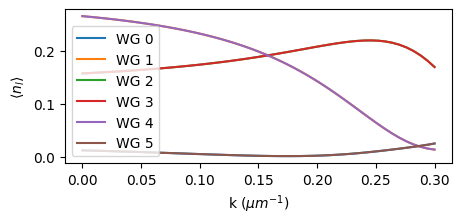

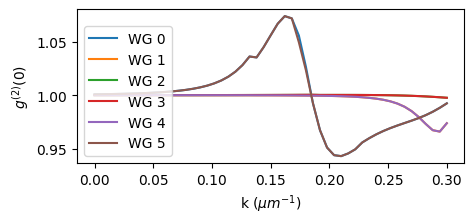

In [112]:
import matplotlib.pyplot as plt

hg = 50
gamma = 0.04
phi = 1

ks = d[hg][gamma][phi]['ks']
g2s = d[hg][gamma][phi]['g2s']
ns = d[hg][gamma][phi]['ns']

legend = [f"WG {i}" for i in range(d[hg][gamma][phi]['parameters']['num_channels'])]

plt.figure(figsize=(5,2))
plt.plot(ks, ns)
plt.xlabel(r"k $(\mu m ^{-1})$")
plt.ylabel(r"$\langle n_l \rangle$")
plt.legend(legend, loc="lower left")
plt.show()

plt.figure(figsize=(5,2))
plt.plot(ks, g2s)
plt.xlabel(r"k $(\mu m ^{-1})$")
plt.ylabel(r"$g^{(2)}(0)$")
plt.legend(legend, loc="lower left")
plt.show()

# Minimal g2 value, as function of phi

In [114]:
import numpy as np

ks = d[10][0.00][0.0]['ks']

g2_min = np.zeros((len(list_hg), len(list_gamma)))
n_g2_min = np.zeros((len(list_hg), len(list_gamma)))

for ih, hg in enumerate(list_hg):
    for ig, gamma in enumerate(list_gamma):
        g2_min_phi = [np.nanmin(d[hg][gamma][phi]['g2s']) for phi in list_phi]
        g2_min[ih,ig] = np.min(g2_min_phi)

        g2_min_arg_phi = [np.unravel_index(np.argmin(d[hg][gamma][phi]['g2s']), data_shape) for phi in list_phi]
        g2_min_arg = g2_min_arg_phi[np.argmin(g2_min_phi)]

        n_g2_min[ih,ig] = d[hg][gamma][phi]['ns'][g2_min_arg]
        

    

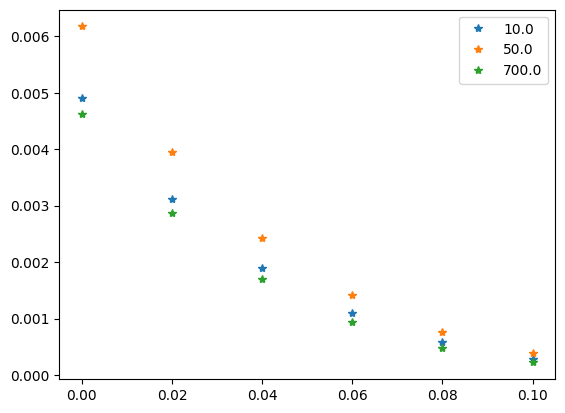

In [117]:
plt.plot(list_gamma, n_g2_min[:].T, '*')
plt.legend(list_hg)

In [45]:
np.min([np.nanmin(d[700][0.0][phi]['g2s']) for phi in list_phi])

np.float64(0.16840273246789234)

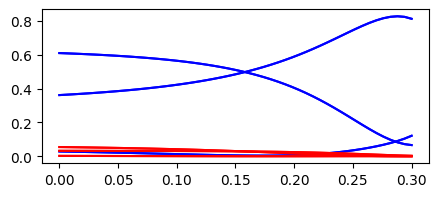

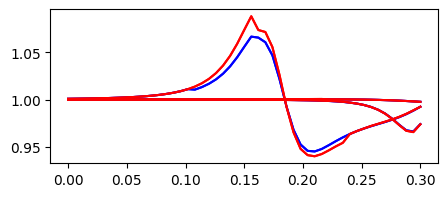

In [102]:
plt.figure(figsize=(5,2))
plt.plot(ks, d[50][0.0][1.]['ns'],'b')
plt.plot(ks, d[50][0.1][1.]['ns'], 'r')
plt.show()

plt.figure(figsize=(5,2))
plt.plot(ks, d[50][0.0][1.]['g2s'],'b')
plt.plot(ks, d[50][0.1][1.]['g2s'], 'r')
plt.show()

In [54]:
np.nanmin(d[700][1.0][0.0]['ns'])

/tmp/ipykernel_1402090/431364603.py:1: RuntimeWarning: All-NaN slice encountered
  np.nanmin(d[700][1.0][0.0]['ns'])


np.float64(nan)